# I - Funções de Transferência

### 1 - Fazer o exercício 2.5, pag. 45 do livro, usando a função conv2. Usar tambem o comando spy para observar as regiões de suporte do filtro, do sinal e do sinal filtrado.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
## conv2d com origem arbitraria  
def conv2d(x, h, origin):
    x = np.asarray(x)
    h = np.asarray(h)
    Hx, Wx = x.shape
    Hh, Wh = h.shape
    oy, ox = origin

    y = np.zeros((Hx + Hh - 1, Wx + Wh - 1))

    for xr in range(Hx):
        for xc in range(Wx):
            for kr in range(Hh):
                for kc in range(Wh):
                    yr = xr + (kr - oy)
                    yc = xc + (kc - ox)

                    y[yr, yc] += x[xr, xc] * h[kr, kc]

    return y

# plot spy 
def plot_spy(x, h, y):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].spy(x, markersize=20)
    ax[0].set_title("Suporte do sinal x")

    ax[1].spy(h, markersize=20)
    ax[1].set_title("Suporte do filtro h")

    ax[2].spy(y, markersize=20)
    ax[2].set_title("Suporte da convolução y=x**h")

    plt.show()

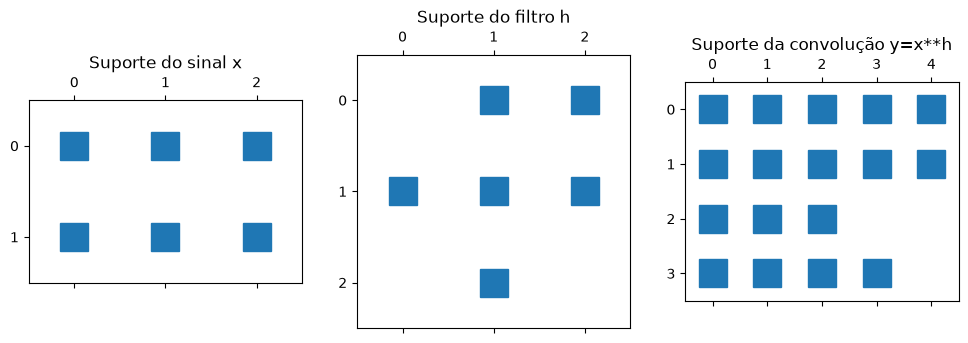

In [17]:
## 1) 
x = [[1,4,1],[2,5,3]]
# 2,5,3 origin 

# i) 
h1 = np.array([[0, -1, 1], [-1, 4, -1], [0, -1, 0]])
origin_h1 = (1, 1)

h1_x = conv2d(x, h1, origin_h1)
plot_spy(x, h1, h1_x)

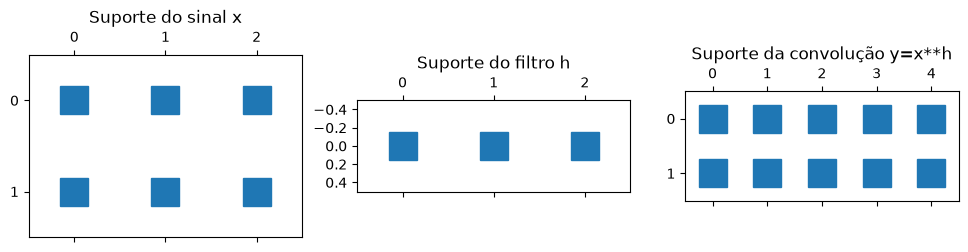

In [18]:
# ii)
h2 = np.array([[1, 2, 3]])
origin_h2 = (0, 1)

h2_x = conv2d(x, h2, origin_h2)
plot_spy(x, h2, h2_x)

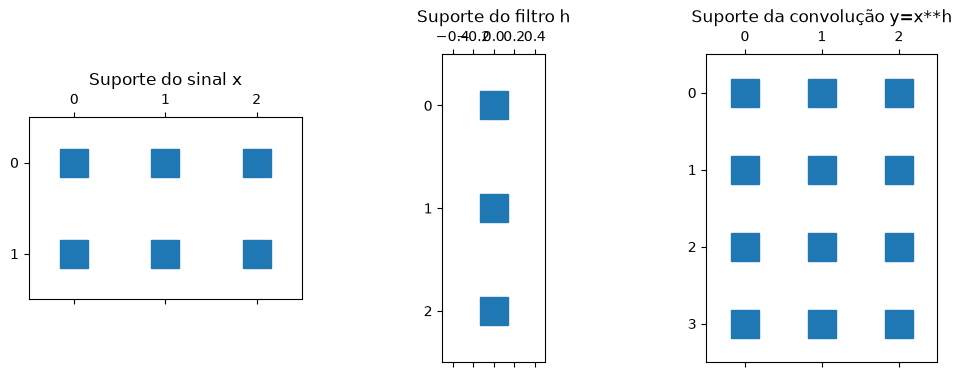

In [19]:
# iii)
h3 = np.array([[-2], [3], [-1]])
origin_h3 = (1, 0)

h3_x = conv2d(x, h3, origin_h3)
plot_spy(x, h3, h3_x)

### 2 - Idem para o sinal x(m, n) representado pela matriz X e h(m, n) representado pela matriz h:

In [15]:
# Signal X
X = np.array(
    [
        [0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 1, 1, 1, 0, 0],
        [0, 0, 1, 1, 1, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
    ],
    dtype=int,
)

# Filter h
h = np.array(
    [
        [0, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 1, 1, 0, 0],
        [0, 1, 1, 0, 0],
        [0, 1, 1, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 0, 0, 0],
    ],
    dtype=int,
)

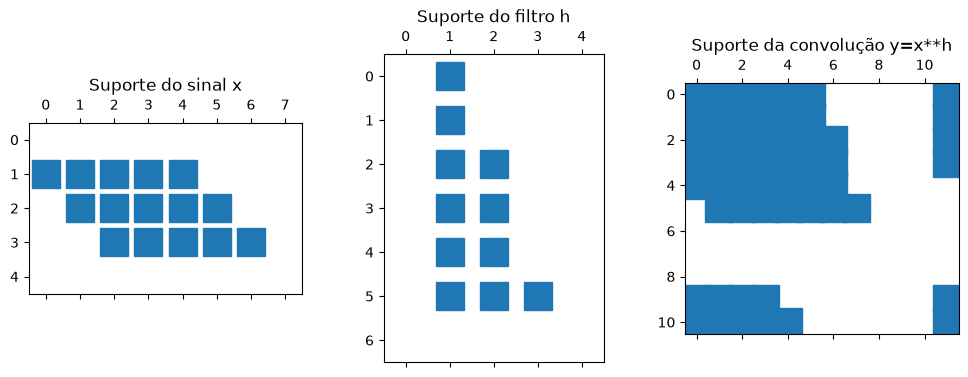

In [16]:
x_h = conv2d(X, h, origin=(3, 2))
plot_spy(X, h, x_h)

# II - Transformadas de Fourier

In [ ]:
from math import pi, sqrt
import matplotlib.pyplot as plt
import numpy as np


def generate_func(theta, d, x, n):
    # theta is in radians; pi is used in the sinusoidal angular frequency
    return 0.5 + 0.5 * np.sin((2 * pi / d) * (x * np.cos(theta) + n * np.sin(theta)))


# Plot the function for paired theta and d values
theta_degrees = [0, 0, 0, 0, 90, 90, 90, 90, 90, 90, 45, 45, 30, 70]
theta_values = np.deg2rad(theta_degrees)
d_values = [
    256,
    150,
    64 * sqrt(2),
    64,
    25,
    16 * sqrt(2),
    10,
    4,
    2,
    1,
    32,
    32 * sqrt(2),
    16,
    4,
]


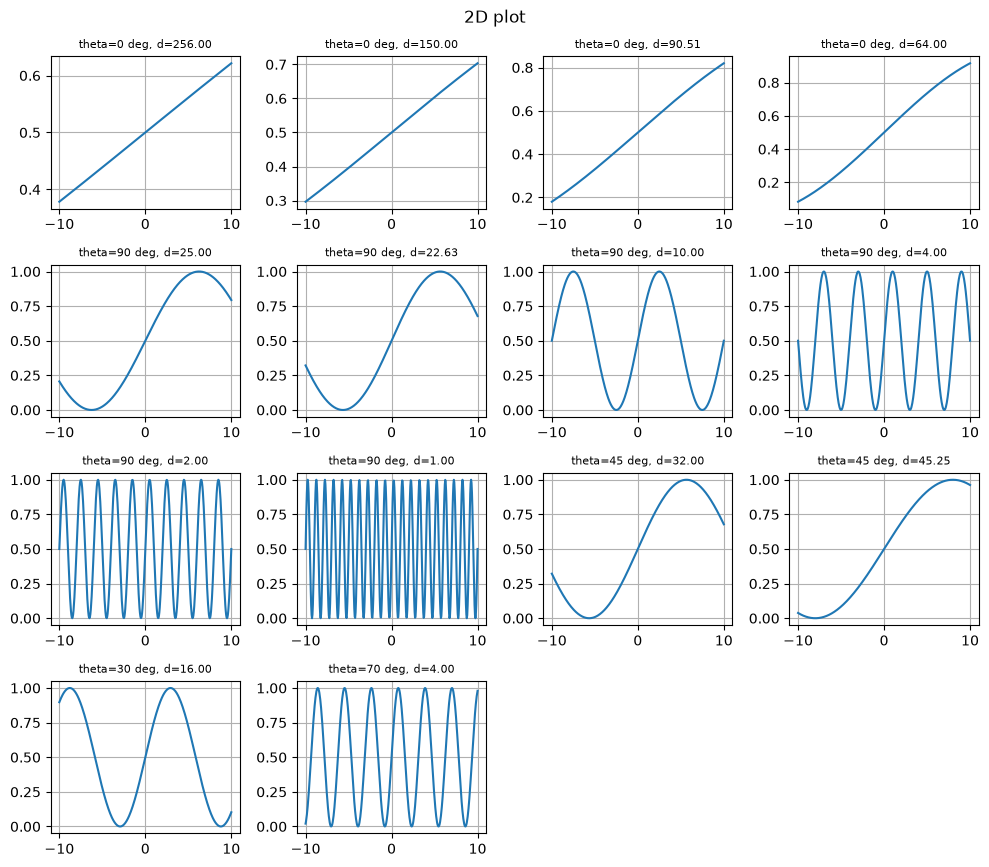

In [23]:
## 1) Gere
def plot_func(theta_values, d_values):
    x = np.linspace(-10, 10, 400)

    n_items = len(theta_values)
    n_cols = int(np.ceil(np.sqrt(n_items)))
    n_rows = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.5 * n_cols, 2.2 * n_rows),
        squeeze=False,
    )

    for idx, (theta, d, theta_deg) in enumerate(zip(theta_values, d_values, theta_degrees)):
        row = idx // n_cols
        col = idx % n_cols
        y = generate_func(theta, d, x, x)
        ax = axes[row, col]
        ax.plot(x, y)
        ax.set_title(f'theta={theta_deg:g} deg, d={d:.2f}', fontsize=8)
        ax.grid(True)

    for idx in range(n_items, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')

    fig.suptitle('2D plot')
    fig.tight_layout()
    fig.savefig('generated_function_plot.png', dpi=100)
    plt.show()

plot_func(theta_values, d_values)

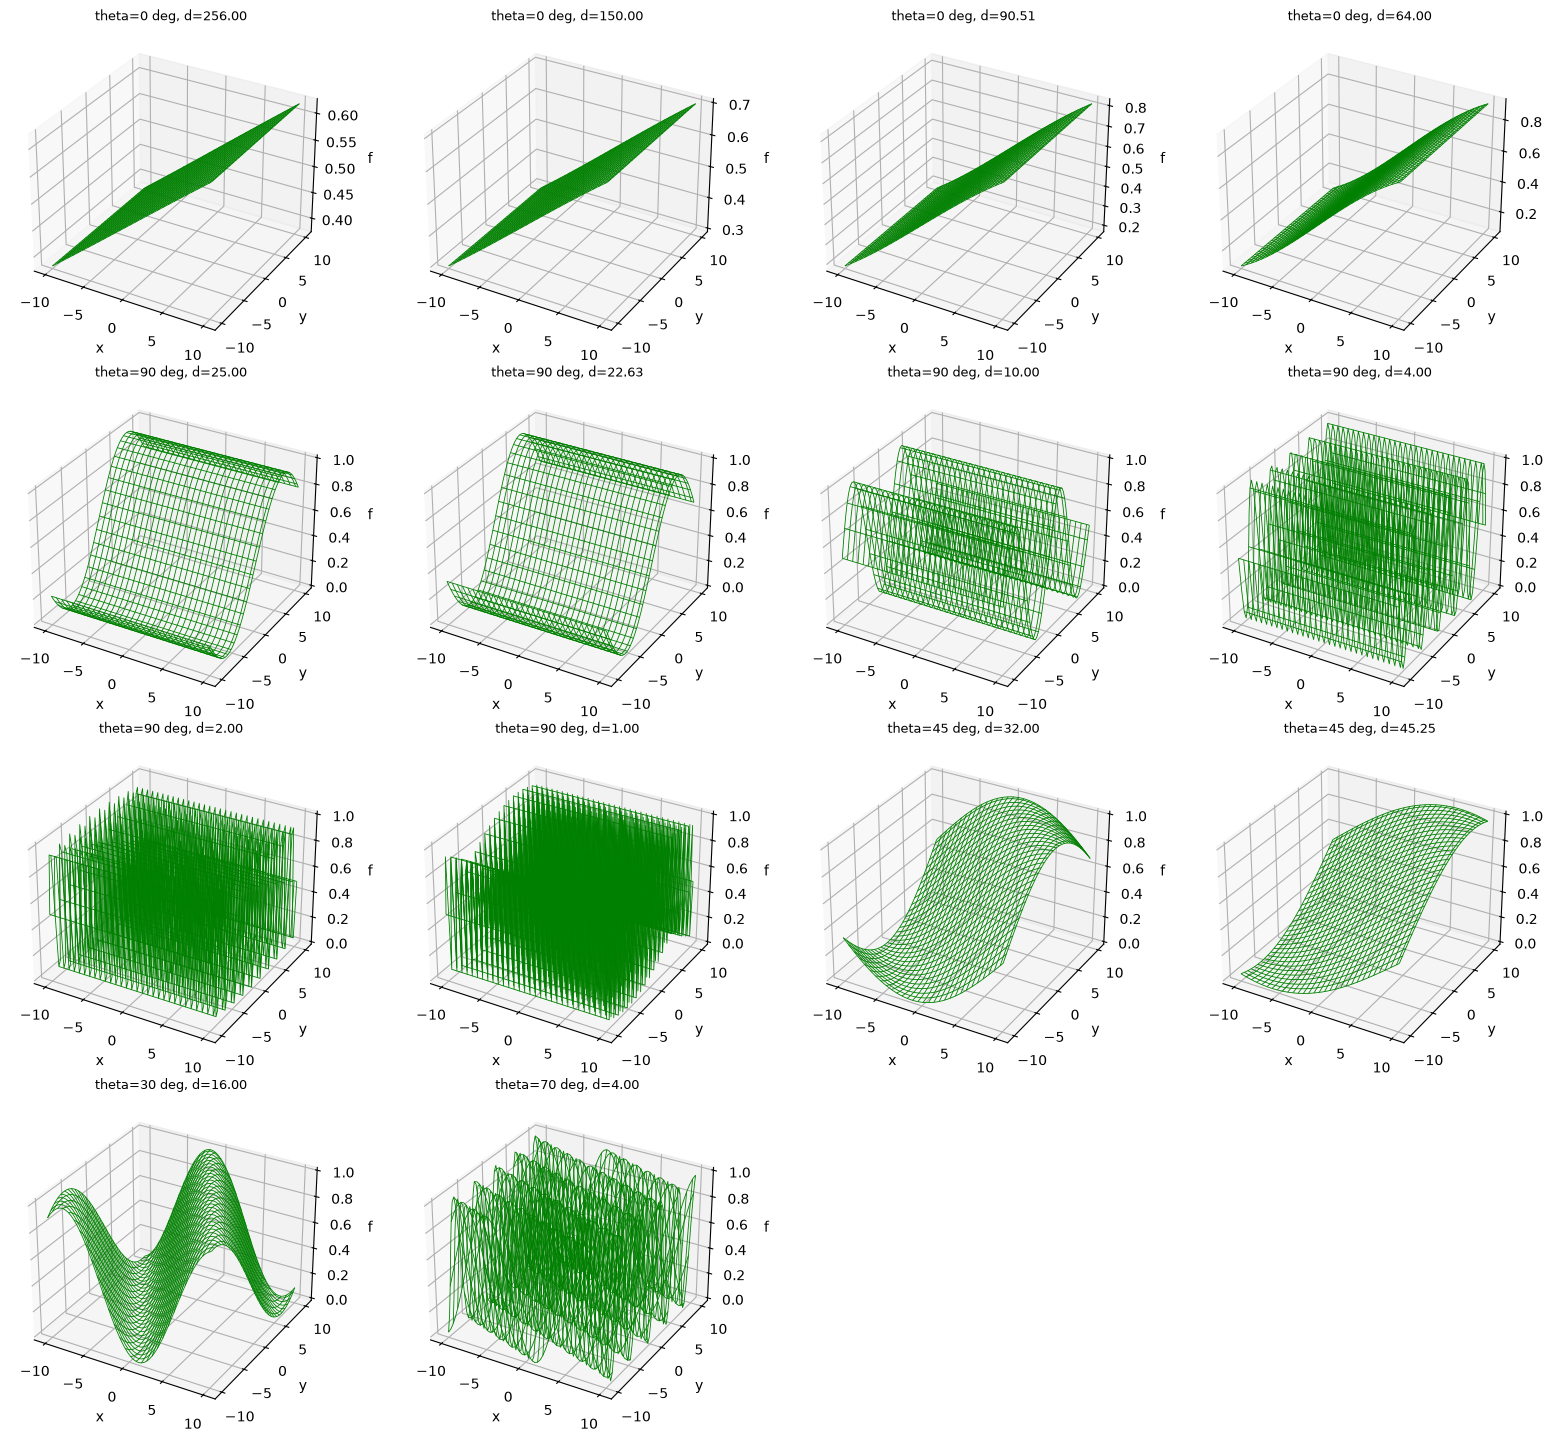

In [27]:
# 3D mesh grid (paired theta and d values)

# Define linear space (-10, 10)
x = np.linspace(-10, 10, 60)
y = np.linspace(-10, 10, 60)
X, Y = np.meshgrid(x, y)

n_items = len(theta_values)
n_cols = int(np.ceil(np.sqrt(n_items)))
n_rows = int(np.ceil(n_items / n_cols))

fig = plt.figure(figsize=(4.0 * n_cols, 3.6 * n_rows))

for idx, (theta, d, theta_deg) in enumerate(zip(theta_values, d_values, theta_degrees)):
    ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')
    Z = generate_func(theta, d, X, Y)
    ax.plot_wireframe(X, Y, Z, rstride=2, cstride=2, color='green', linewidth=0.6)
    ax.set_title(f'theta={theta_deg:g} deg, d={d:.2f}', fontsize=9)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f')

fig.tight_layout()
plt.show()
fig.savefig('generated_function_3D_plot.png', dpi=100)
